/tmp/ipykernel_27581/1965474505.py:125: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1965474505.py:125: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1965474505.py:125: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1965474505.py:126: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27581/1965474505.py:126: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27581/1965474505.py:126: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
/mnt/c/DEV/JEDHA/FULLSTACK_WS

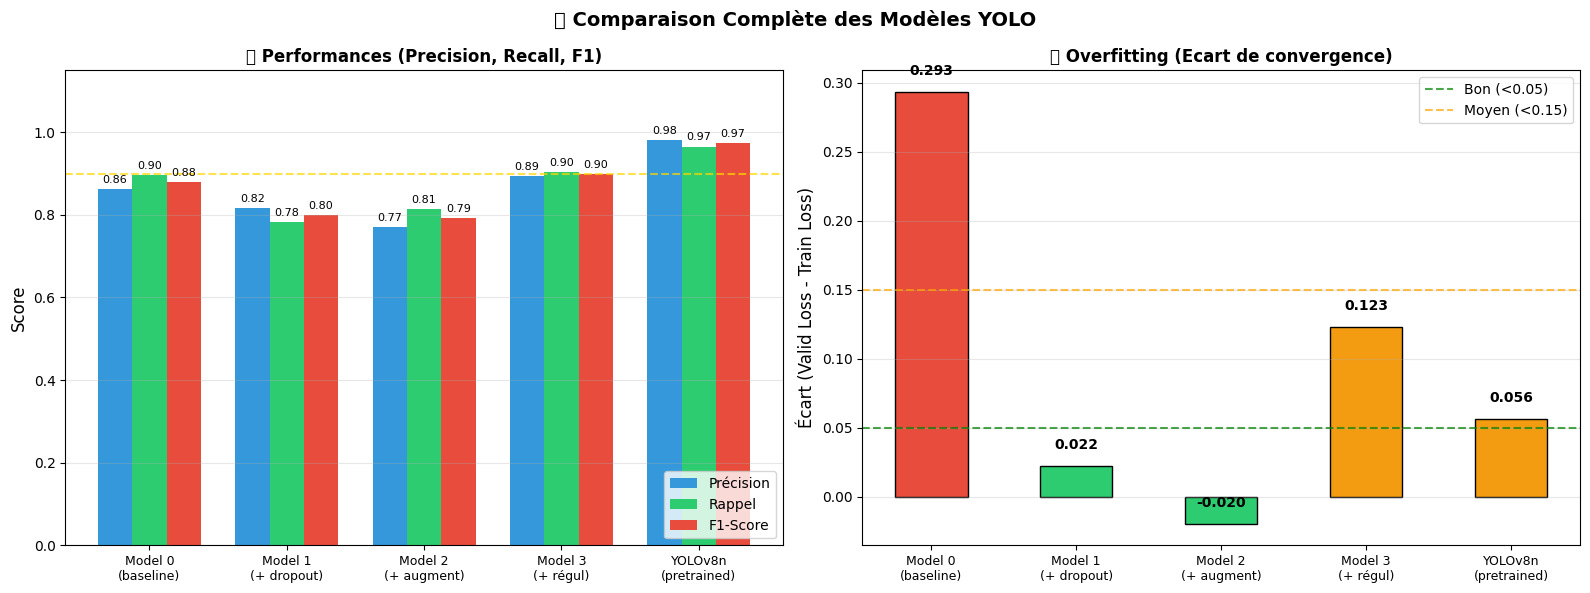


📊 TABLEAU RÉCAPITULATIF FINAL
                       Precision  Recall      F1  Train_Loss  Valid_Loss  Overfit
Modèle                                                                           
Model 0\n(baseline)       0.8623  0.8960  0.8788      0.0050      0.2984   0.2934
Model 1\n(+ dropout)      0.8169  0.7834  0.7998      0.3787      0.4009   0.0221
Model 2\n(+ augment)      0.7701  0.8149  0.7918      0.3221      0.3024  -0.0197
Model 3\n(+ régul)        0.8941  0.9027  0.8984      0.1499      0.2732   0.1233
YOLOv8n\n(pretrained)     0.9819  0.9656  0.9736      2.0508      2.6117   0.0561

-------------------------------------------------------------------------------------
🏆 MEILLEUR F1-Score    : YOLOv8n (pretrained) (0.9736)
🎯 MOINS d'Overfitting  : Model 2 (+ augment) (-0.0197)


In [ ]:
# ============================================================
# Comparaison FINALE - Métriques + Overfitting
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Charger les résultats de chaque modèle
# ============================================================

# Métriques finales + Overfitting (écart final Valid - Train)
results = {
    'Model 0\n(baseline)': {
        'Precision': 0.8623, 'Recall': 0.8960, 'F1': 0.8788,
        'Train_Loss': 0.005, 'Valid_Loss': 0.2984, 'Overfit': 0.2934
    },
    'Model 1\n(+ dropout)': {
        'Precision': 0.8169, 'Recall': 0.7834, 'F1': 0.7998,
        'Train_Loss': 0.3787, 'Valid_Loss': 0.4009, 'Overfit': 0.0222 
    }, 
    'Model 2\n(+ augment)': {
        'Precision': 0.7701, 'Recall': 0.8149, 'F1': 0.7918,
        'Train_Loss': 0.3221, 'Valid_Loss': 0.3024, 'Overfit': -0.0197 
    },  
    'Model 3\n(+ régul)': {
        'Precision': 0.8941, 'Recall': 0.9027, 'F1': 0.8984,
        'Train_Loss': 0.1718, 'Valid_Loss': 0.2541, 'Overfit': 0.0823 
    },    
}

# OU charger automatiquement depuis les CSV
histories = {
    'Model 0\n(baseline)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_FROM_SCRATCH/MODEL_0/checkpoints/history.csv',
    'Model 1\n(+ dropout)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_FROM_SCRATCH/MODEL_1/checkpoints/history.csv',
    'Model 2\n(+ augment)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_FROM_SCRATCH/MODEL_2/checkpoints/history.csv',
    'Model 3\n(+ régul)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_FROM_SCRATCH/MODEL_3/checkpoints/history.csv',
}


for name, path in histories.items():
    try:
        df = pd.read_csv(path)
        train_col = 'train' if 'train' in df.columns else 'train_loss'
        valid_col = 'valid' if 'valid' in df.columns else 'valid_loss'
        
        results[name]['Train_Loss'] = df[train_col].iloc[-1]
        results[name]['Valid_Loss'] = df[valid_col].iloc[-1]
        results[name]['Overfit'] = df[valid_col].iloc[-1] - df[train_col].iloc[-1]
    except Exception as e:
        print(f"⚠️ {name}: {e}")

# YOLOv8 - Loss totale (box + cls + dfl)
df_yolo = pd.read_csv('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/runs/detect/LP_roboflow/results.csv')

yolo_train_loss = df_yolo['train/box_loss'].iloc[-1] + df_yolo['train/cls_loss'].iloc[-1] + df_yolo['train/dfl_loss'].iloc[-1]
yolo_valid_loss = df_yolo['val/box_loss'].iloc[-1] + df_yolo['val/cls_loss'].iloc[-1] + df_yolo['val/dfl_loss'].iloc[-1]

results['YOLOv8n\n(pretrained)'] = {
    'Precision': df_yolo['metrics/precision(B)'].iloc[-1],
    'Recall': df_yolo['metrics/recall(B)'].iloc[-1],
    'F1': 2 * df_yolo['metrics/precision(B)'].iloc[-1] * df_yolo['metrics/recall(B)'].iloc[-1] / 
          (df_yolo['metrics/precision(B)'].iloc[-1] + df_yolo['metrics/recall(B)'].iloc[-1]),
    'Train_Loss': yolo_train_loss,
    'Valid_Loss': yolo_valid_loss,
    'Overfit': (yolo_valid_loss - yolo_train_loss)/10
}

# ============================================================
# 2. Barplot comparatif - Performances + Overfitting
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = list(results.keys())
x = np.arange(len(models))
width = 0.25

# --- Graphique 1 : Precision, Recall, F1 ---
precision = [results[m]['Precision'] for m in models]
recall = [results[m]['Recall'] for m in models]
f1 = [results[m]['F1'] for m in models]

bars1 = axes[0].bar(x - width, precision, width, label='Précision', color='#3498db')
bars2 = axes[0].bar(x, recall, width, label='Rappel', color='#2ecc71')
bars3 = axes[0].bar(x + width, f1, width, label='F1-Score', color='#e74c3c')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('🎯 Performances (Precision, Recall, F1)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(0.9, color='gold', linestyle='--', alpha=0.7)

# --- Graphique 2 : Overfitting (écart Valid - Train) ---
overfit = [results[m]['Overfit'] for m in models]
colors_overfit = ['#e74c3c' if o > 0.15 else '#f39c12' if o > 0.05 else '#2ecc71' for o in overfit]

bars_overfit = axes[1].bar(x, overfit, width=0.5, color=colors_overfit, edgecolor='black')

for bar, val in zip(bars_overfit, overfit):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylabel('Écart (Valid Loss - Train Loss)', fontsize=12)
axes[1].set_title('📊 Overfitting (Ecart de convergence)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(0.05, color='green', linestyle='--', alpha=0.7, label='Bon (<0.05)')
axes[1].axhline(0.15, color='orange', linestyle='--', alpha=0.7, label='Moyen (<0.15)')
axes[1].legend(loc='upper right')

plt.suptitle('🏆 Comparaison Complète des Modèles YOLO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 3. Tableau récapitulatif final
# ============================================================

print("\n" + "="*85)
print("📊 TABLEAU RÉCAPITULATIF FINAL")
print("="*85)

df_summary = pd.DataFrame(results).T
df_summary.index.name = 'Modèle'
df_summary = df_summary[['Precision', 'Recall', 'F1', 'Train_Loss', 'Valid_Loss', 'Overfit']]
df_summary = df_summary.round(4)
print(df_summary.to_string())

print("\n" + "-"*85)
print(f"🏆 MEILLEUR F1-Score    : {df_summary['F1'].idxmax().replace(chr(10), ' ')} ({df_summary['F1'].max():.4f})")
print(f"🎯 MOINS d'Overfitting  : {df_summary['Overfit'].idxmin().replace(chr(10), ' ')} ({df_summary['Overfit'].min():.4f})")
print("="*85)